<a href="https://colab.research.google.com/github/EmilianoCastelan/Simulacion1/blob/main/TIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random as r
import numpy as np
import matplotlib.pyplot as plt

Primero, creamos nuestra función de la distribución de probabilidad triangular para simular los pesos de las tinas

In [ ]:
def triangular(a, b, c, n): #a=primer punto de la gráfica, b=segundo punto de la gráfica, c=punto maximo, n=número de tinas
    lista = []
    Fc = (c - a) / (b - a)

    for i in range(n):
        u = r.random()

        if u < Fc:
            x = a + np.sqrt(u * (b - a) * (c - a))
        else:
            x = b - np.sqrt((1 - u) * (b - a) * (b - c))

        lista.append(float(x))

    return lista

In [ ]:
triangular(190,230,210,5)

[190.7258979853609,
 197.07838489630024,
 220.94639015037404,
 206.49817318428407,
 209.37063883886856]

In [ ]:
def Pesotinas(m):   #m sera el número de simulaciones que se haran
  lista_tinas=[]
  suma_tinas=[]
  for i in range(m):
    xi=triangular(190,230,210,5)
    lista_tinas.append(xi)
    np.sum(lista_tinas[i])  #aquí, se realiza la suma de las tinas
    suma_tinas.append(float(np.sum(lista_tinas[i])))
  return suma_tinas


In [144]:
PT=Pesotinas(100)

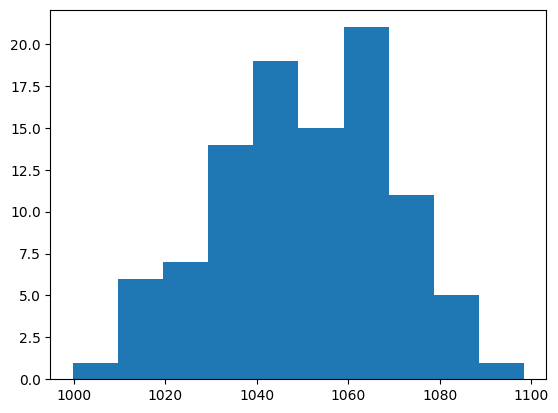

In [145]:
plt.hist(PT,bins=10)
plt.show()

In [150]:
def peso_camion(lotes):
    probabilidades_por_lote = []
    m = 1000  # número de simulaciones por lote

    for i in range(lotes):
        # Obtener una lista de 'm' sumas de cargas de camión para el lote actual
        sumas_lote_actual = Pesotinas(m)

        cargas_aceptables = 0

        # Revisar cada suma del lote
        for suma in sumas_lote_actual:
            if suma <= 1000:
                cargas_aceptables += 1

        # Calcular la probabilidad del lote
        if m > 0:
            probabilidad_lote = cargas_aceptables / m
        else:
            probabilidad_lote = 0  # evitar división por cero

        probabilidades_por_lote.append(probabilidad_lote)

    # Calcular el promedio de probabilidades
    if len(probabilidades_por_lote) > 0:
        probabilidad_promedio = np.mean(probabilidades_por_lote)
    else:
        probabilidad_promedio = 0

    return probabilidad_promedio

In [153]:
peso_camion(100)

np.float64(0.00238)

In [154]:
def promedio_prom(n):
  promedio=[]
  for i in range(n):
    promedio.append(peso_camion(100))
  return np.mean(promedio)

Con esto, podemos concluir que hay una probabilidad del 1-0.00249=0.99751=99.75% de que el peso exceda la tonelada,aproximadamente